Plot saved to LPSIFNg-state-specific-Alleles.pdf


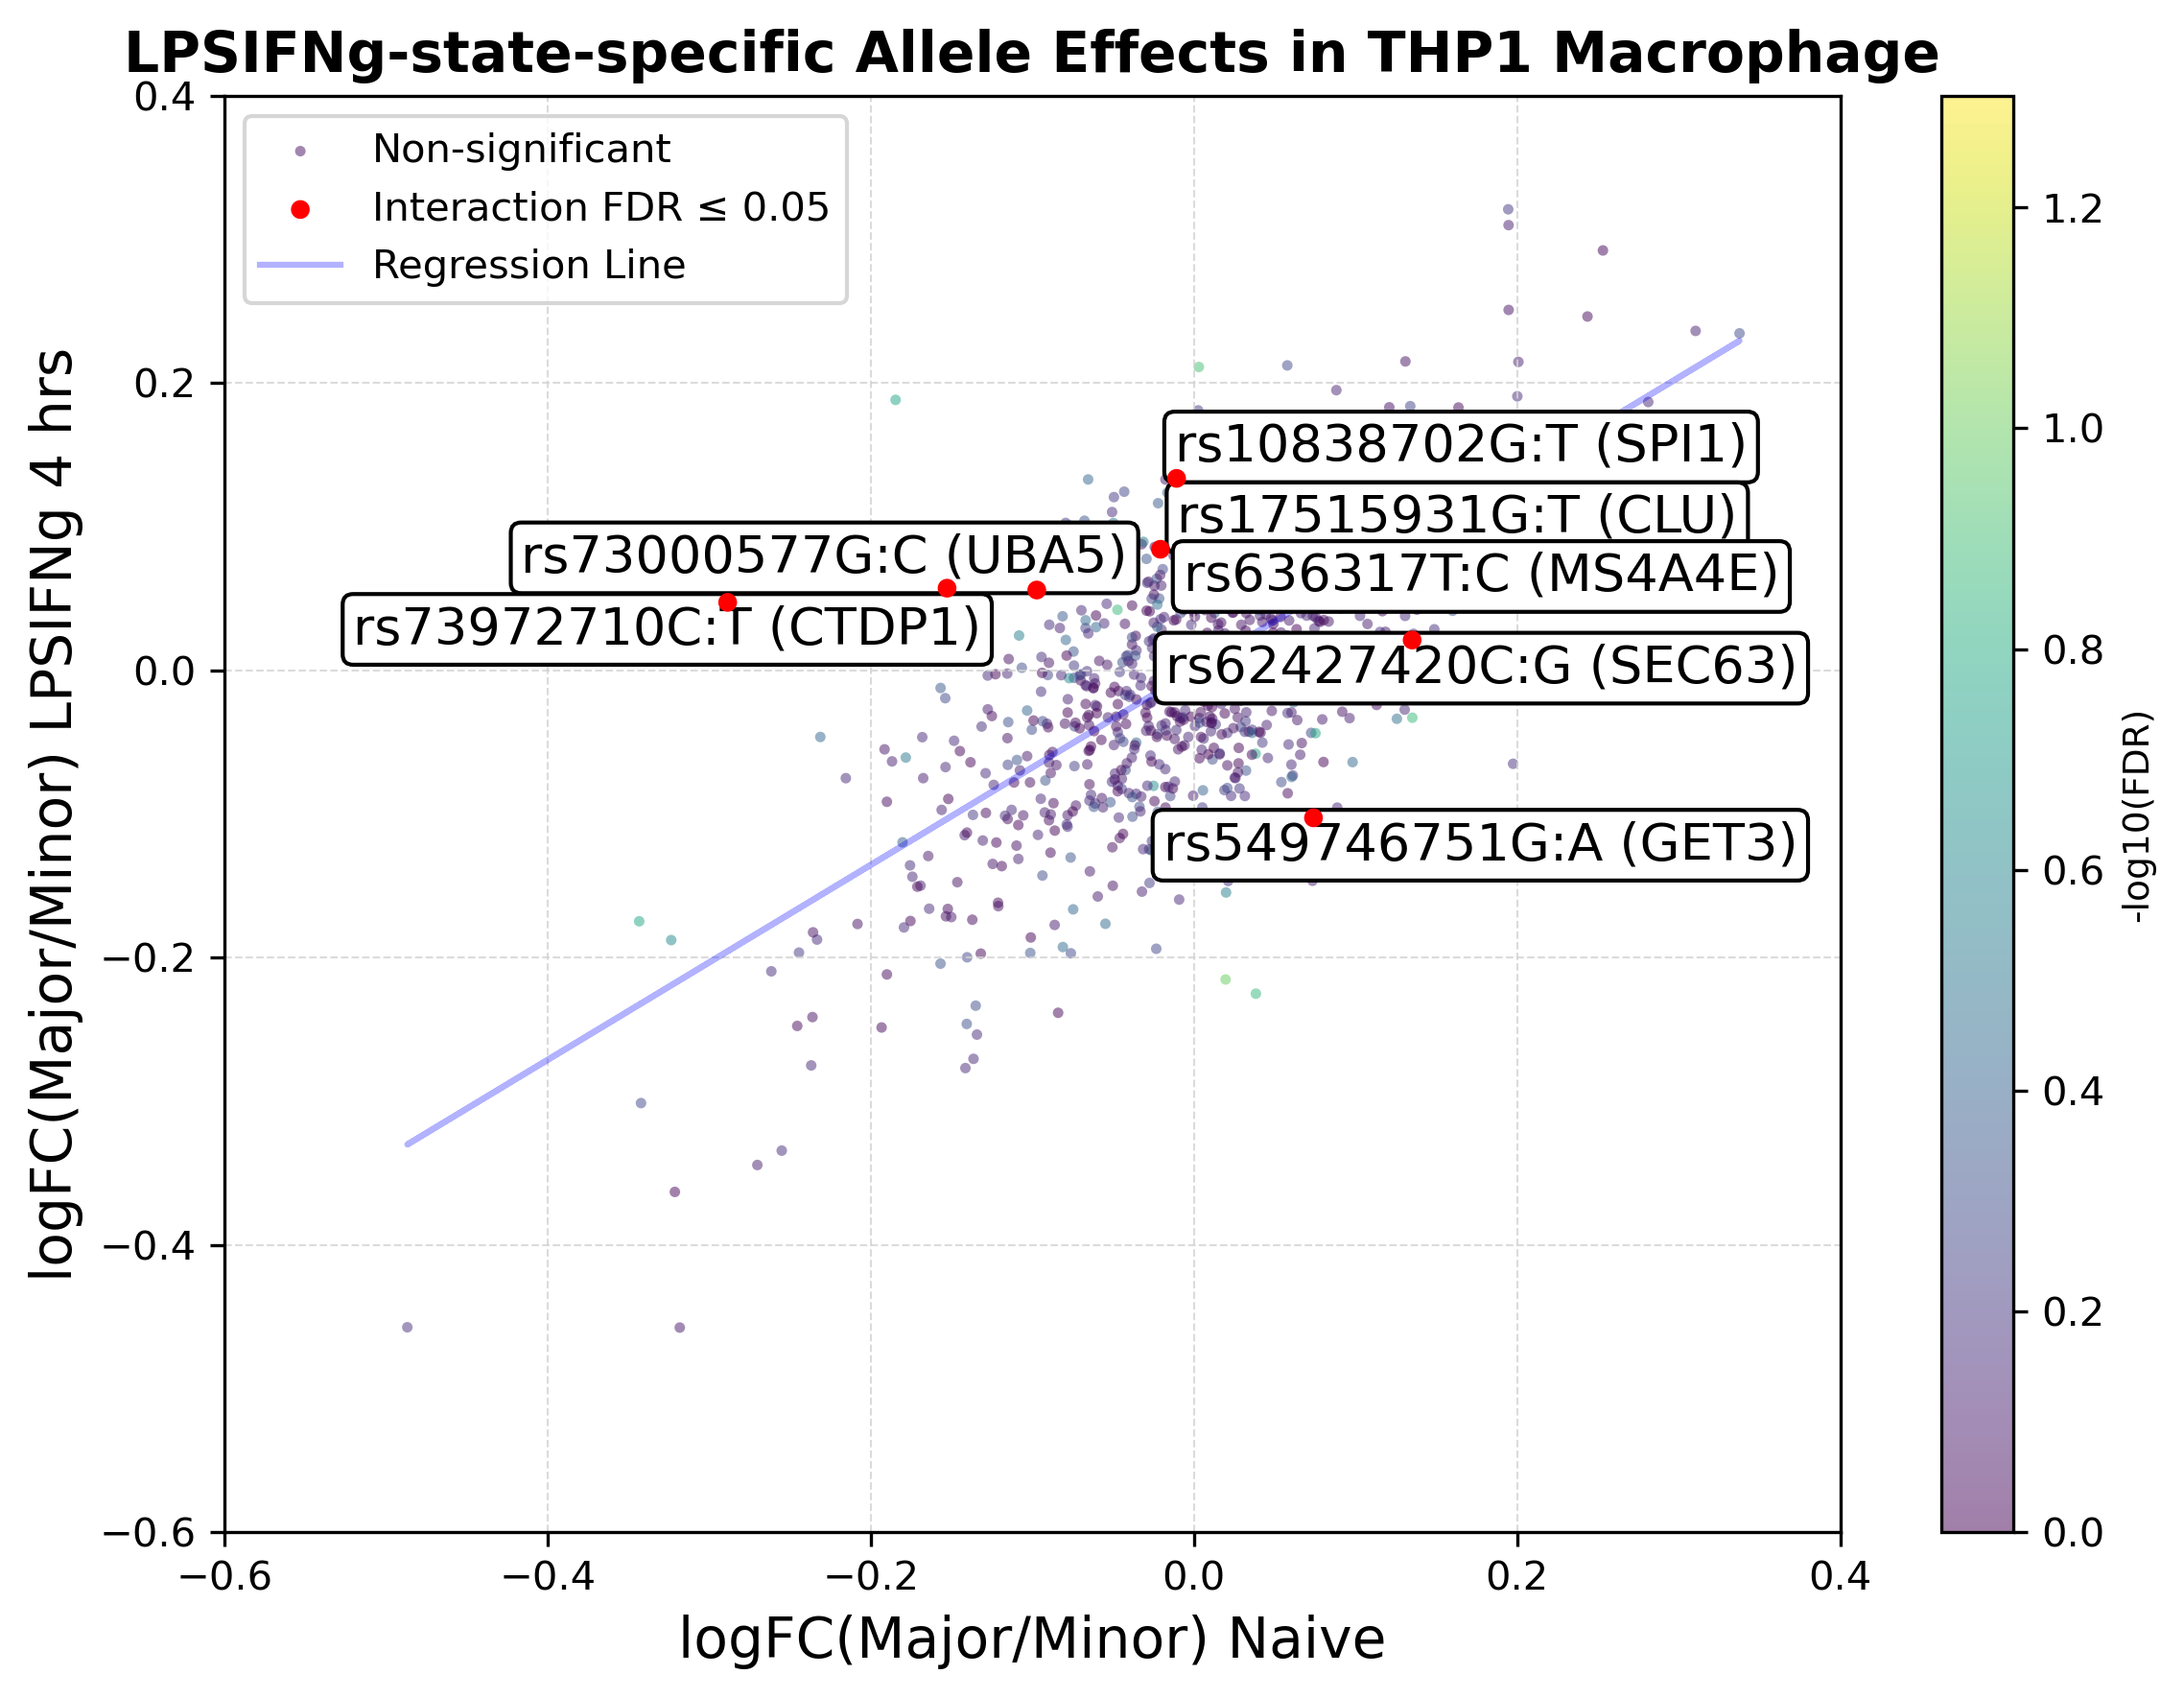

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import pandas as pd

def plot_logFC_scatter_withFDR(
    lps,
    naive,
    interaction_df,
    x_label,
    y_label,
    title,
    difference_threshold=2,
    save_file=None
):
    """
    Plot scatter of logFC from LPS and Naive datasets with:
      - A linear regression line
      - Outlier detection (optional labeling)
      - Point color determined by -log10(FDR), with FDR<=0.05 points in red

    Parameters:
    -----------
    lps : pd.DataFrame
        DataFrame containing logFC values for LPS condition
    naive : pd.DataFrame
        DataFrame containing logFC values for Naive condition
    interaction_df : pd.DataFrame
        DataFrame containing 'fdr' column to control color coding
    x_label : str
        Label for the x-axis
    y_label : str
        Label for the y-axis
    title : str
        Title for the plot
    difference_threshold : float
        Threshold in standard deviations to define outliers
    save_file : str, optional
        Path to save the plot as an image
    """

    # Merge LPS and Naive data on matching indices
    df_cluster = (
        lps[['logFC']].rename(columns={'logFC': 'logFC_LPS'})
        .merge(
            naive[['logFC']].rename(columns={'logFC': 'logFC_Naive'}),
            left_index=True,
            right_index=True
        )
    )
    df_index = pd.read_csv("/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv", index_col=0)
    df_cluster['rsid_gene_tss'] = df_index['rsid_gene_tss']
    df_cluster['REFALT_Flip'] = df_index['REFALT_Flip']
    df_cluster['logFC_LPS'] = df_cluster['logFC_LPS'] * df_cluster['REFALT_Flip'].apply(lambda x: -1 if x else 1)
    df_cluster['logFC_Naive'] = df_cluster['logFC_Naive'] * df_cluster['REFALT_Flip'].apply(lambda x: -1 if x else 1)
    # Join with interaction DF to get FDR
    df_cluster = df_cluster.join(interaction_df[['fdr']], how='inner')

    # Define the x and y variables
    x = df_cluster['logFC_Naive'].values.reshape(-1, 1)
    y = df_cluster['logFC_LPS'].values

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    # Calculate residuals and define outliers (optional)
    residuals = y - y_pred
    threshold = difference_threshold * np.std(residuals)
    df_cluster['Residual'] = residuals
    df_cluster['Outlier'] = np.abs(residuals) > threshold

    # Create a -log10(FDR) column
    df_cluster['neg_logFDR'] = -np.log10(df_cluster['fdr'])

    # Mask of significant vs. non-significant
    sig_mask = df_cluster['fdr'] <= 0.05
    nonsig_mask = ~sig_mask

    # Prepare figure
    plt.figure(figsize=(8, 6), dpi=300)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.8)

    # --- Scatter for non-significant points ---
    sc = plt.scatter(
        df_cluster['logFC_Naive'],
        df_cluster['logFC_LPS'],
        c=df_cluster['neg_logFDR'],
        cmap='viridis',
        alpha=0.5,
        s=7,
        edgecolor='none',
        label='Non-significant',
        vmax=-np.log10(0.05)
    )

    cbar = plt.colorbar(sc)
    cbar.set_label('-log10(FDR)', fontsize=9)
    # --- Scatter for significant points (red) ---
    plt.scatter(
        df_cluster.loc[sig_mask, 'logFC_Naive'],
        df_cluster.loc[sig_mask, 'logFC_LPS'],
        color='red',
        alpha=1,
        s=22,
        edgecolor='none',
        label='Interaction FDR ≤ 0.05',
        zorder=3  # Ensures these points are on top
    )

    # --- Plot the regression line ---
    plt.plot(
        df_cluster['logFC_Naive'],
        y_pred,
        color='blue',
        linewidth=1.5,
        alpha=0.3,
        label='Regression Line'
    )

        # --- Create labels for significant points ---
    texts = []
    for idx, row in df_cluster[sig_mask].iterrows():
        # Place the label directly at the point (no offset), or use a small offset if desired
        t = plt.text(
            row['logFC_Naive'],
            row['logFC_LPS'],
            row['rsid_gene_tss'],
            fontsize=13,
            color='black',
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black'),
            zorder=2  # Ensure text is under red dots
        )
        texts.append(t)

    # Use adjust_text to avoid overlapping labels; arrow lines connect label to point if moved
    adjust_text(
        texts,
        force_text=(0.1, 0.2),         # Lower force keeps labels closer
        force_points=(0.2, 0.2),
        #arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
        only_move={'text':'xy', 'points':'xy'}
    )

    # --- Figure formatting ---
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    plt.title(title, fontsize=14, weight='bold')
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.ylim(-0.6, 0.4)
    plt.xlim(-0.6, 0.4)

    # Save the plot if required
    if save_file:
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_file}")

    plt.show()

# Read your dataframes
df_interaction = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only_interaction/20240812_comparative_THP1_LPSIFNGvsNaive_interaction.csv',index_col=0)
# Check -log10(FDR)
neglogFDR = -np.log10(df_interaction['fdr'])
lps = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only/20240616_comparative_THP1_LPSIFNG_alleleOnly.csv',index_col=0)
naive = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only/20240616_comparative_THP1_Naive_alleleOnly.csv',index_col=0)

# Now plot
plot_logFC_scatter_withFDR(
    lps=lps,
    naive=naive,
    interaction_df=df_interaction,
    x_label='logFC(Major/Minor) Naive',
    y_label='logFC(Major/Minor) LPSIFNg 4 hrs',
    title='LPSIFNg-state-specific Allele Effects in THP1 Macrophage',
    difference_threshold=3,
    save_file='LPSIFNg-state-specific-Alleles.pdf')
